# 1) Data exploration

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import warnings
warnings.filterwarnings("ignore")

### Import data

In [36]:
# title,img_url,description,ratings,n_votes,is_adult,production_year,runtime,genres,release_year,studio,img_embeddings,text_embeddings

X1 = pd.read_csv("X1.csv")
X2 = pd.read_csv("X2.csv")
Y1 = pd.read_csv("Y1.csv", header=None, names=['revenue'])

split = X1['genres'].str.split(',')
X1['genres']=split
split = X2['genres'].str.split(',')
X2['genres']=split


X1["img_embeddings_array"] =  [ast.literal_eval(X1['img_embeddings'][i]) for i in range(len(X1))]
X1["text_embeddings_array"] = [ast.literal_eval(X1['text_embeddings'][i]) for i in range(len(X1))]

X2 ["img_embeddings_array"] =  [ast.literal_eval(X2['img_embeddings'][i]) for i in range(len(X2))]
X2 ["text_embeddings_array"] = [ast.literal_eval(X2['text_embeddings'][i]) for i in range(len(X2))]


Y1["log_revenue"] = np.log(Y1)["revenue"]

X1["exp_ratings"] = np.exp(X1["ratings"])
X1["log_ratings"] = np.log(X1["ratings"])
X1["log_n_votes"] = np.log(X1["n_votes"])



### Revenue

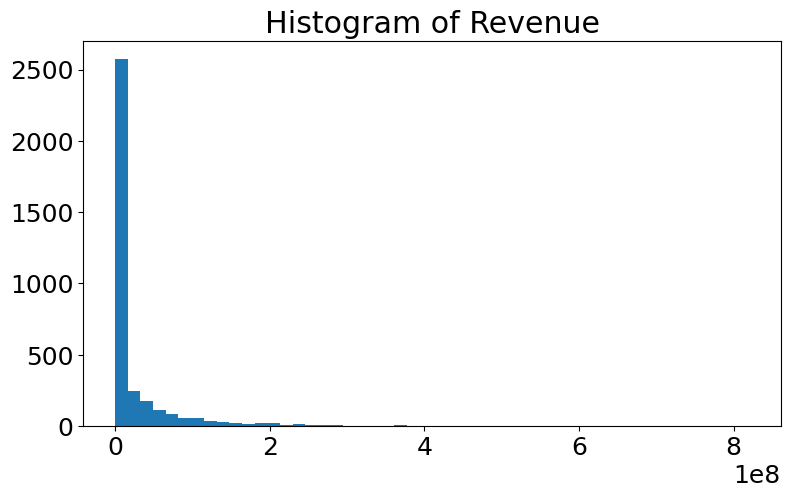

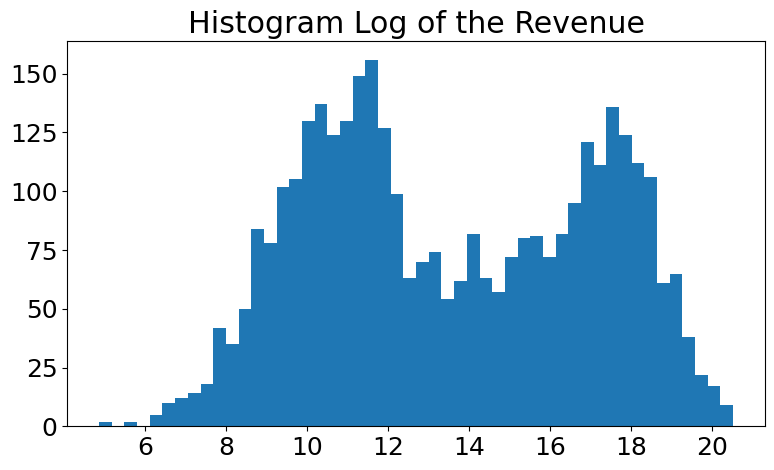

In [37]:
# revenue

nbcolums = 50
plt.rc("font", size=18)
plt.figure(figsize=(9,5))
plt.hist(Y1['revenue'], bins=nbcolums)
plt.title('Histogram of Revenue')
plt.show()

plt.rc("font", size=18)
plt.figure(figsize=(9,5))
plt.hist(Y1['log_revenue'], bins=nbcolums)
plt.title('Histogram Log of the Revenue')
plt.show()


### Are there "nan" in our data ?

In [38]:
print("Number of NaN in X2 for each feature :\n", X2.isna().sum())
print("Number of NaN in X1 for each feature :\n", X1.isna().sum())

# So there is no NaN in our features

Number of NaN in X2 for each feature :
 Unnamed: 0               0
title                    0
img_url                  0
description              0
ratings                  0
n_votes                  0
is_adult                 0
production_year          0
runtime                  0
genres                   0
release_year             0
studio                   0
img_embeddings           0
text_embeddings          0
img_embeddings_array     0
text_embeddings_array    0
dtype: int64
Number of NaN in X1 for each feature :
 Unnamed: 0               0
title                    0
img_url                  0
description              0
ratings                  0
n_votes                  0
is_adult                 0
production_year          0
runtime                  0
genres                   0
release_year             0
studio                   0
img_embeddings           0
text_embeddings          0
img_embeddings_array     0
text_embeddings_array    0
exp_ratings              0
log_ratings     

### Plot of some features

Text(0, 0.5, 'Logarithm of revenue')

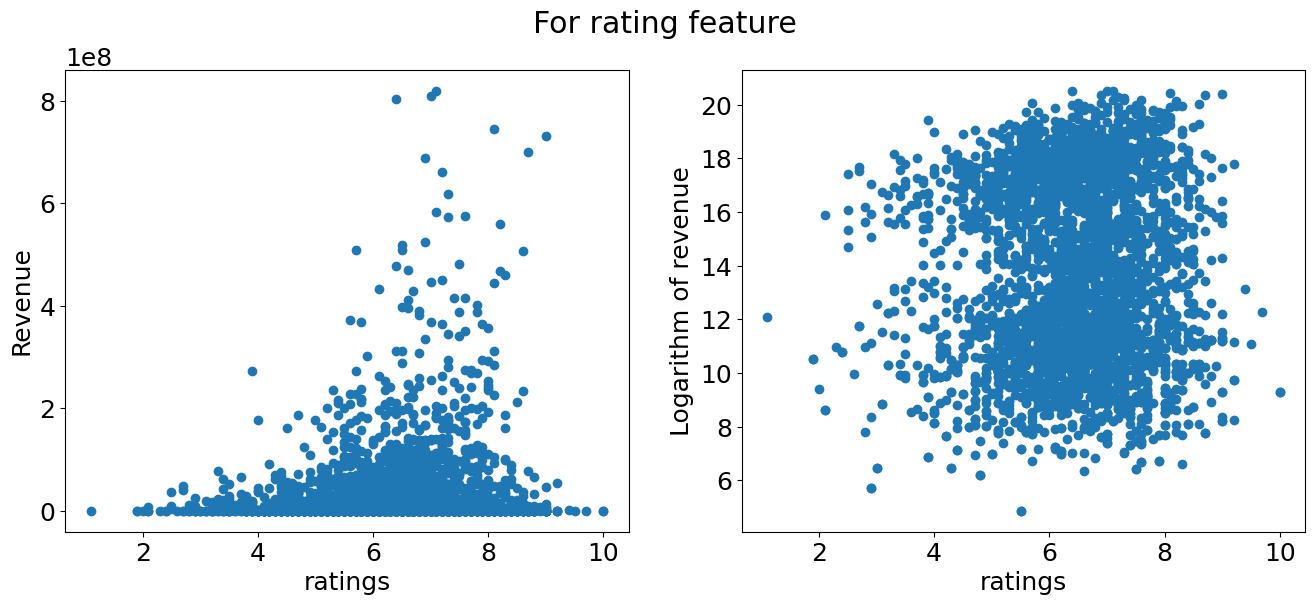

In [39]:
# ratings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle('For rating feature')
ax1.plot(X1['ratings'], Y1['revenue'], 'o')
ax1.set_xlabel("ratings")
ax1.set_ylabel("Revenue")

ax2.plot(X1['ratings'], np.log(Y1['revenue']), 'o')
ax2.set_xlabel("ratings")
ax2.set_ylabel("Logarithm of revenue")

Text(0, 0.5, 'Logarithm of revenue')

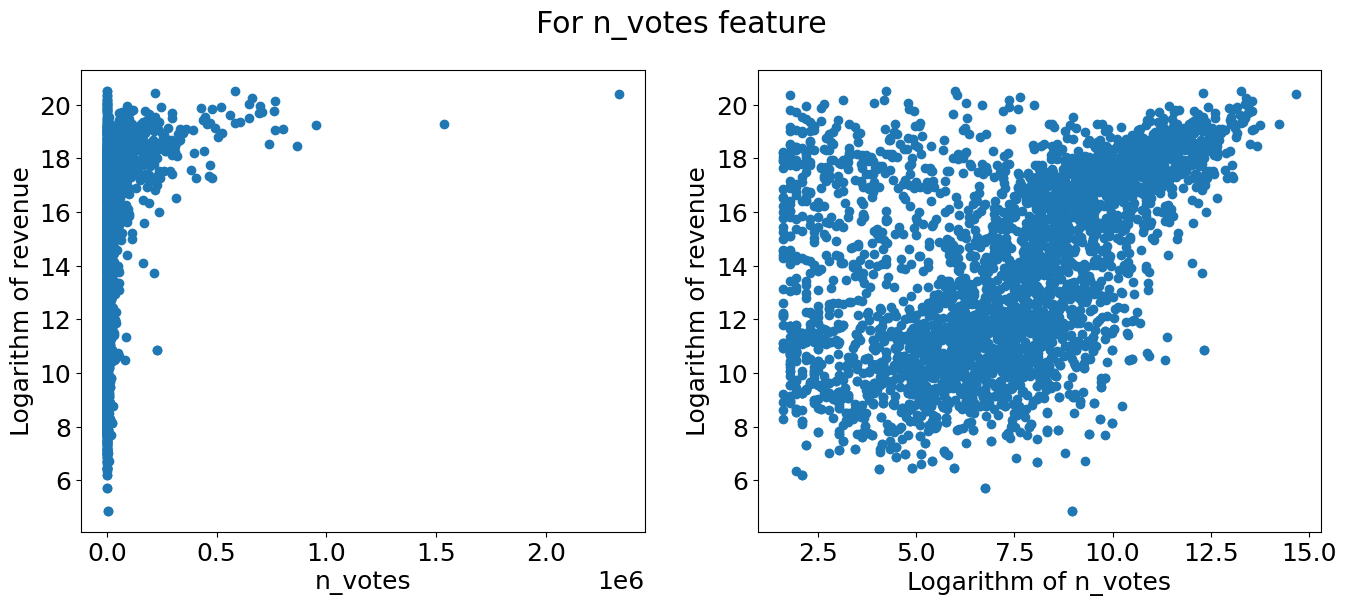

In [40]:
# n_vote
# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,6))
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(16,6))

fig.suptitle('For n_votes feature')

# ax1.plot(X1['n_votes'], Y1['revenue'], 'o')
# ax1.set_xlabel("n_votes")
# ax1.set_ylabel("Revenue")

ax2.plot(X1['n_votes'], np.log(Y1['revenue']), 'o')
ax2.set_xlabel("n_votes")
ax2.set_ylabel("Logarithm of revenue")

ax3.plot(np.log(X1['n_votes']), np.log(Y1['revenue']), 'o')
ax3.set_xlabel("Logarithm of n_votes")
ax3.set_ylabel("Logarithm of revenue")

Text(0, 0.5, 'Logarithm of revenue')

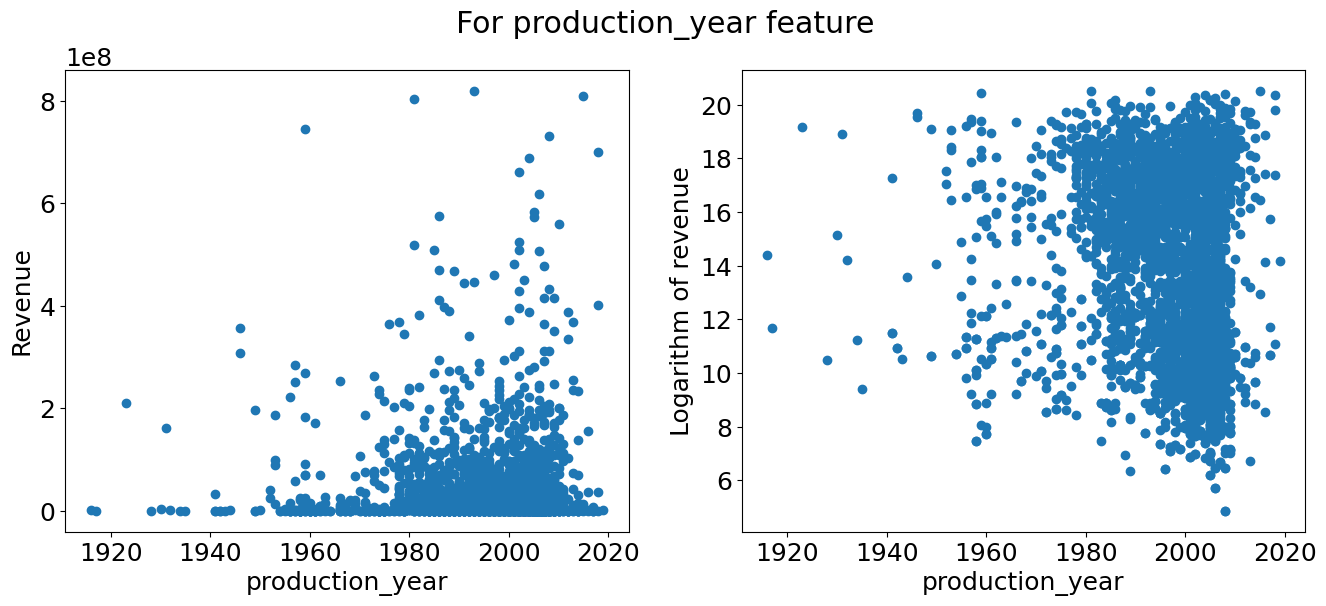

In [41]:
# production_year
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle('For production_year feature')
ax1.plot(X1['production_year'], Y1['revenue'], 'o')
ax1.set_xlabel("production_year")
ax1.set_ylabel("Revenue")

ax2.plot(X1['production_year'], np.log(Y1['revenue']), 'o')
ax2.set_xlabel("production_year")
ax2.set_ylabel("Logarithm of revenue")

### is_adult feature

In [42]:
#is adult

Film_X=False
for i in X1['is_adult']:
    if (i == 1):
        print("on a troué le film X !!!")
        Film_X=True

for i in X2['is_adult']:
    if (i == 1):
        print("on a troué le film X !!!")
        Film_X=True
        
if (Film_X==False):
    print("Il n'y a aucun film X")

# Nous n'avons pas trouvé de film adulte

Il n'y a aucun film X


### Mean predictor

100.24965325505732
100.24965325505732


Text(0.5, 0, 'films ordered by conribution to the RMSE')

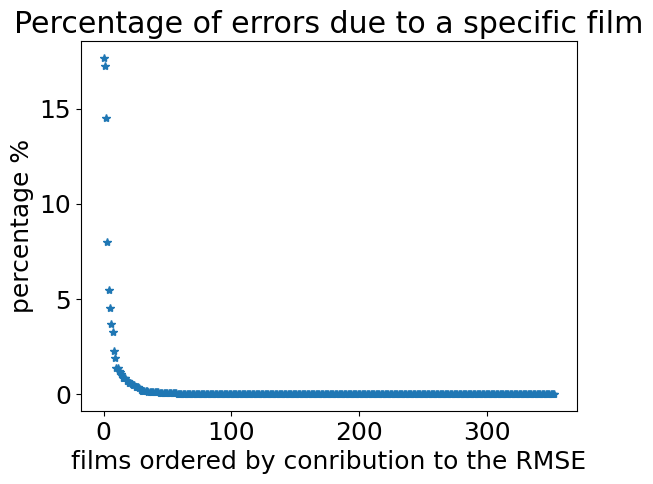

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

y = Y1["revenue"]
y_train_mean, y_test_mean = train_test_split(y, random_state=42, train_size=0.9)


mean = np.mean(y_train_mean)
y_predict_mean = np.ones(len(y_test_mean))*mean


pred_error =mean_squared_error(y_test_mean, y_predict_mean)
print(np.sqrt(pred_error)/1000000)


vec = (y_test_mean-y_predict_mean)**2
print(np.sqrt(sum(vec)/len(vec))/1000000)

vec = vec/sum(vec)*100
vec = sorted(vec, reverse=True)
plt.plot(range(len(vec)), vec, "*")
plt.title("Percentage of errors due to a specific film")
plt.ylabel("percentage %")
plt.xlabel("films ordered by conribution to the RMSE")

### Genre variable

In [44]:
import numpy as np
list_genres = np.unique(np.concatenate(X1['genres']))


for genre in list_genres:
    X1[genre] = [int(genre in X1['genres'][i]) for i in range(len(X1['genres']))]

for genre in list_genres:
    X2[genre] = [int(genre in X2['genres'][i]) for i in range(len(X2['genres']))]


liste = []
for genre in list_genres:
    a = np.sum(X1[genre])
    liste.append(a)


dic = {}
j = 0
for genre in list_genres:
    dic[genre] = liste[j]
    j+=1


X1['genre'] = [sum([dic[i]for i in j])/len(j) for j in X1['genres']]


list_genres = list(list_genres) 


print(list_genres)

['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War', 'Western', '\\N']


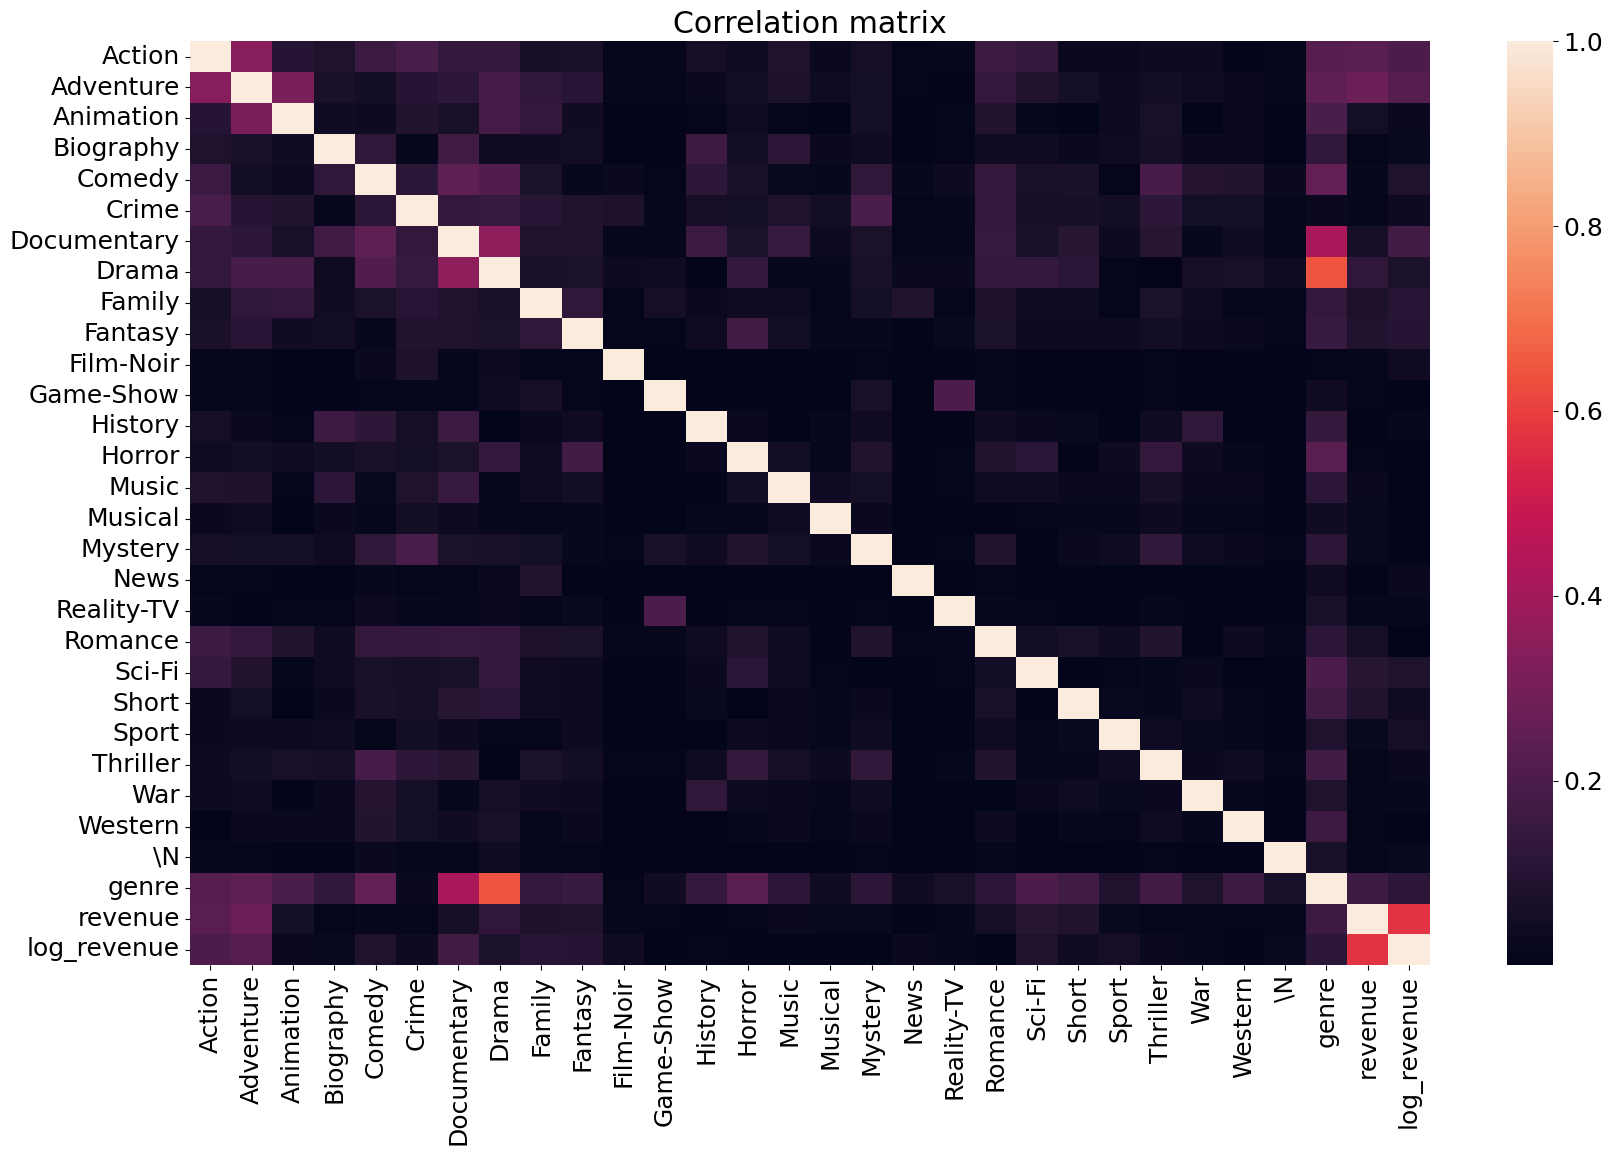

3.125768216578214
3.0967549994402286


In [45]:
import seaborn as sns

Xy_corr_genres = pd.concat([X1[list_genres] , X1['genre'], Y1[["revenue", "log_revenue"]]], axis=1)
plt.rc("font", size=18)
plt.figure(figsize=(20,12))
sns.heatmap(np.abs(Xy_corr_genres.corr()))
plt.title('Correlation matrix')
plt.show()


print(sum(np.abs(Xy_corr_genres.corr())['revenue']))
print(sum(np.abs(Xy_corr_genres.corr())["log_revenue"]))


In [46]:
import numpy as np

A = X1[list_genres]
A = np.asarray(A)
U, S, Vt = np.linalg.svd(A.T)


liste_label_genre = []
for i in range(len(S)):
    X1["gen"+str(i)] = Vt[i]*S[i]
    liste_label_genre.append("gen"+str(i))

nb_compo_img = len(S)



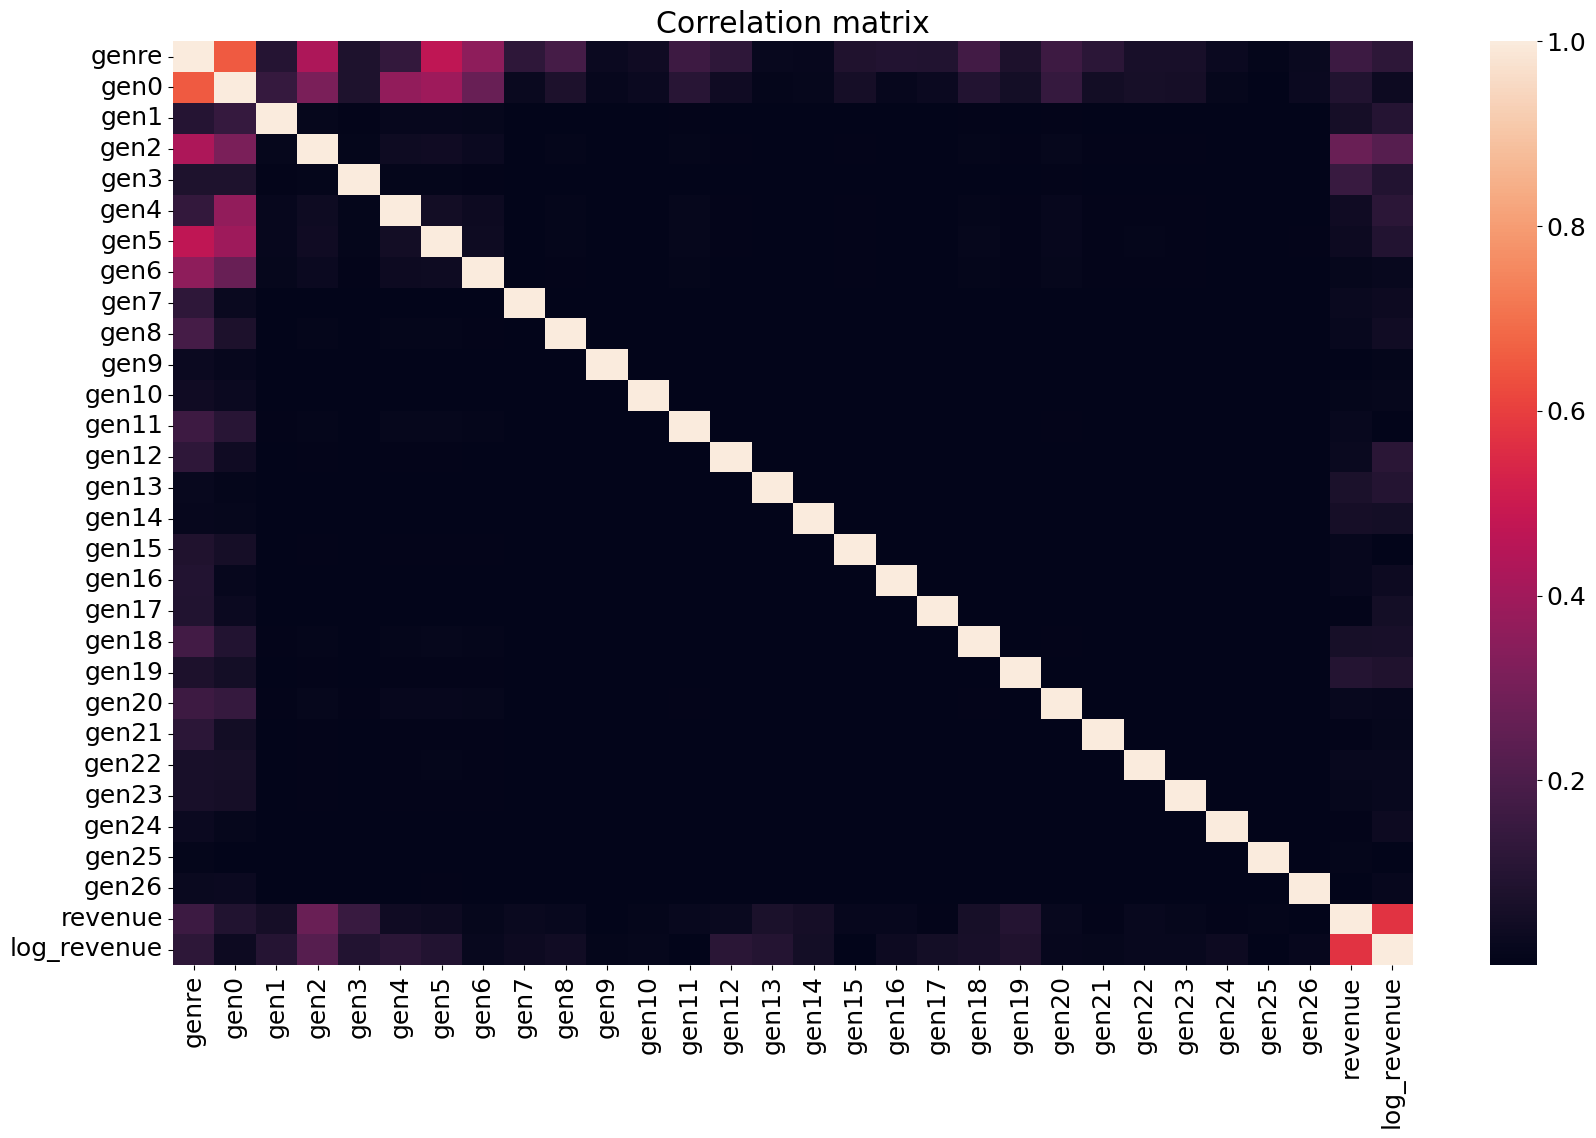

2.882263179918745
3.081525249086293


In [47]:
import seaborn as sns

Xy_corr_genres = pd.concat([ X1['genre'], X1[liste_label_genre] , Y1[["revenue", "log_revenue"]]], axis=1)
plt.rc("font", size=18)
plt.figure(figsize=(20,12))
sns.heatmap(np.abs(Xy_corr_genres.corr()))
plt.title('Correlation matrix')
plt.show()

print(sum(np.abs(Xy_corr_genres.corr())['revenue']))
print(sum(np.abs(Xy_corr_genres.corr())["log_revenue"]))


### Studio variable

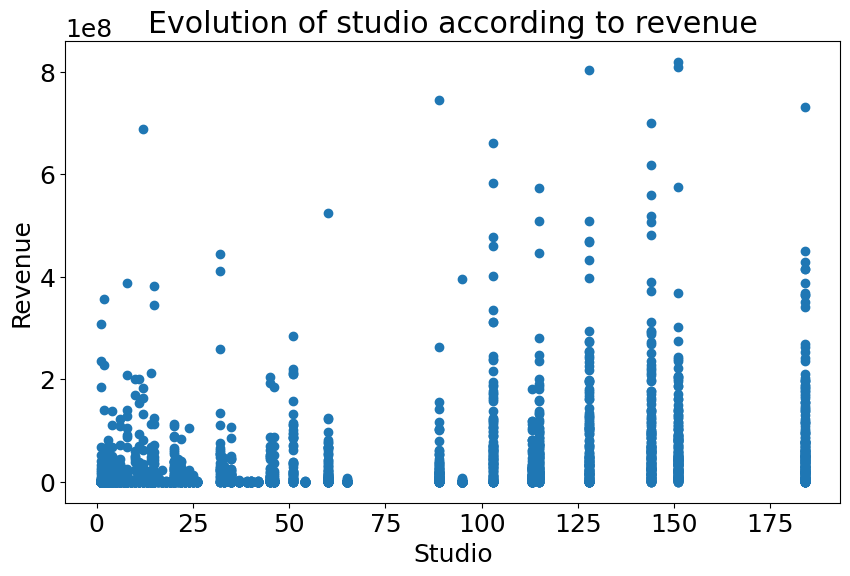

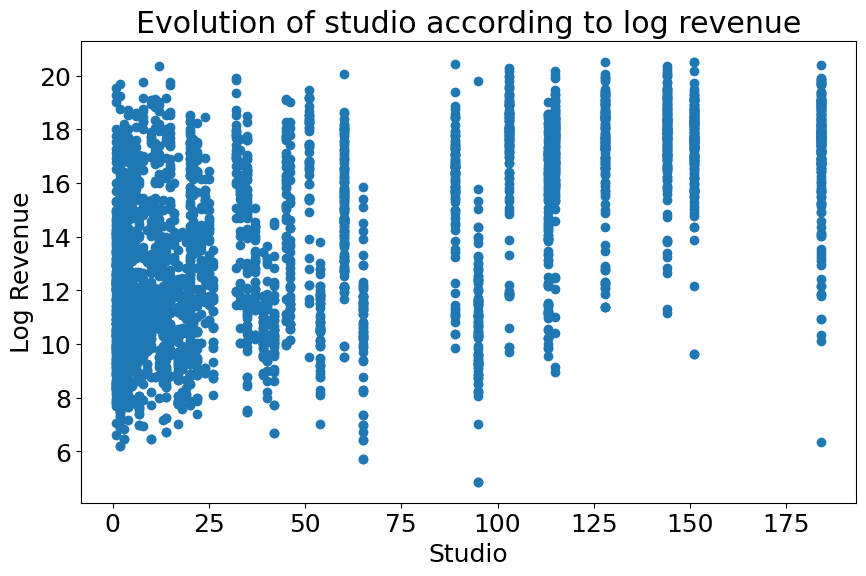

In [48]:
# Studio

X_dum = pd.get_dummies(X1['studio'])

liste = []
for i in X_dum:
    a = np.sum(X_dum[i])
    liste.append(a)


dic = {}
j = 0
for i in X_dum:
    dic[i] = liste[j]
    j+=1


X1['std'] = [dic[i] for i in X1['studio']]

x = X1['std'] # Nombre de film produit par le studio
y1 = Y1['revenue'] 
y2 = Y1['log_revenue']

plt.rc("font", size=18)
plt.figure(figsize=(10,6))
plt.title('Evolution of studio according to revenue')
plt.xlabel("Studio")
plt.ylabel("Revenue")
plt.plot(x, y1, "o")
plt.show()

plt.rc("font", size=18)
plt.figure(figsize=(10,6))
plt.title('Evolution of studio according to log revenue')
plt.xlabel("Studio")
plt.ylabel("Log Revenue")
plt.plot(x, y2, "o")
plt.show()

### Runtime

In [49]:
#replace //N with mean substitution

Xrt = X1['runtime']
nbNan =0

for ind in Xrt.index:
    value = Xrt[ind]
    nbNan += (value=='\\N')
    if( value=='\\N'):
        Xrt = Xrt.drop(ind)

print("The percentage of /N in runtime is : ", (nbNan/len(X1))*100)
mean = np.mean(np.array(Xrt, dtype=float))
print("Runtime average is (in minutes)", mean)



Xrt = X1['runtime']
for ind in Xrt.index:
    if( Xrt[ind]=='\\N'):
        Xrt[ind] = mean


Xrt = pd.DataFrame(Xrt, dtype=float)

X1['runtime']=Xrt
X1['log_runtime'] = np.log(Xrt)


The percentage of /N in runtime is :  7.457627118644068
Runtime average is (in minutes) 92.29334554334554


### Unnamed feature

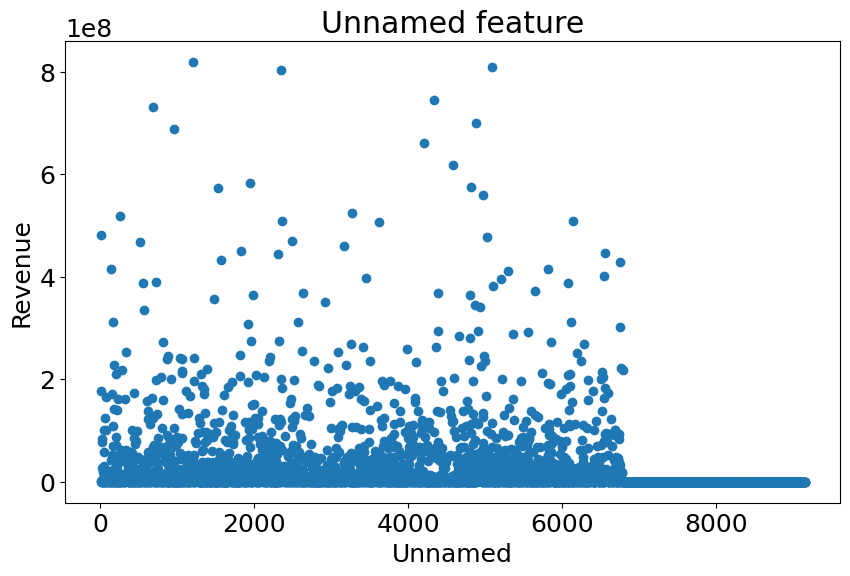

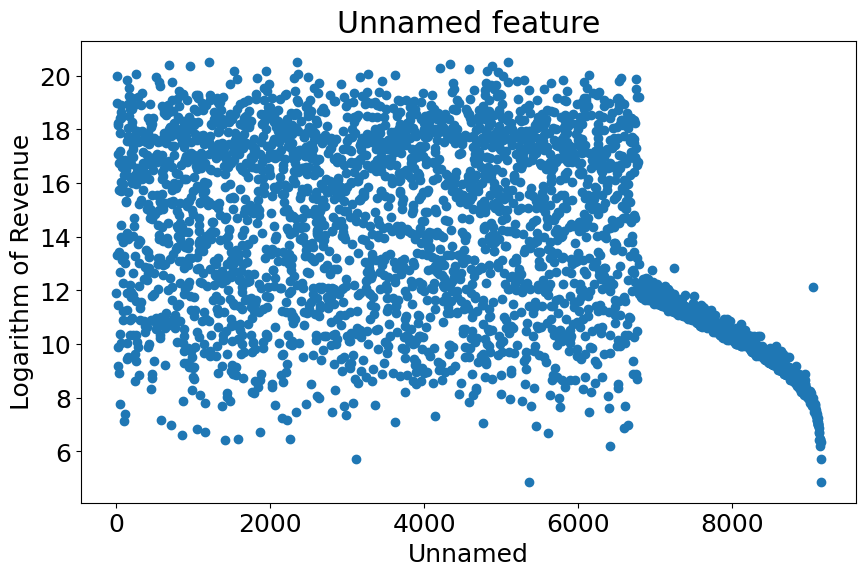

In [50]:
plt.rc("font", size=18)
plt.figure(figsize=(10,6))
plt.plot(X1["Unnamed: 0"], Y1['revenue'], 'o')
plt.xlabel("Unnamed")
plt.ylabel("Revenue")
plt.title("Unnamed feature")
plt.show()

plt.rc("font", size=18)
plt.figure(figsize=(10,6))
plt.plot(X1["Unnamed: 0"], np.log(Y1['revenue']), 'o')
plt.xlabel("Unnamed")
plt.ylabel("Logarithm of Revenue")
plt.title("Unnamed feature")
plt.show()

### Correlation matrix over features

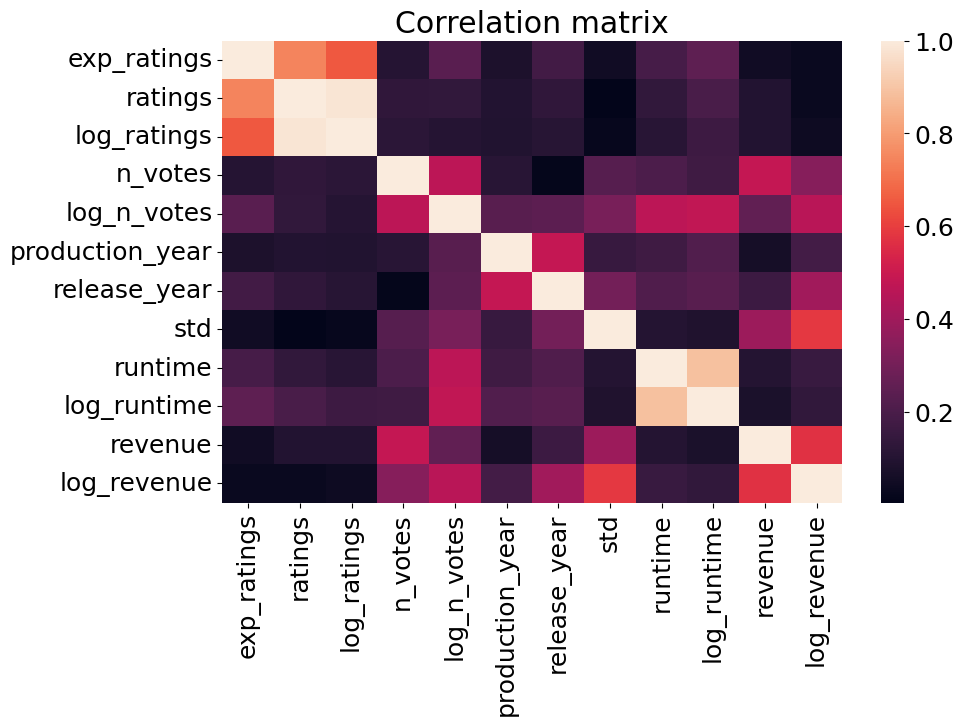

In [51]:
import seaborn as sns

Xy_corr_var_sp = pd.concat([X1[["exp_ratings","ratings", "log_ratings", "n_votes", "log_n_votes",  "production_year", "release_year", "std", "runtime", "log_runtime"]] , Y1[["revenue", "log_revenue"]]], axis=1)

plt.rc("font", size=18)
plt.figure(figsize=(10,6))
sns.heatmap(np.abs(Xy_corr_var_sp.corr()))
plt.title('Correlation matrix')
plt.show()

### Image embeddings

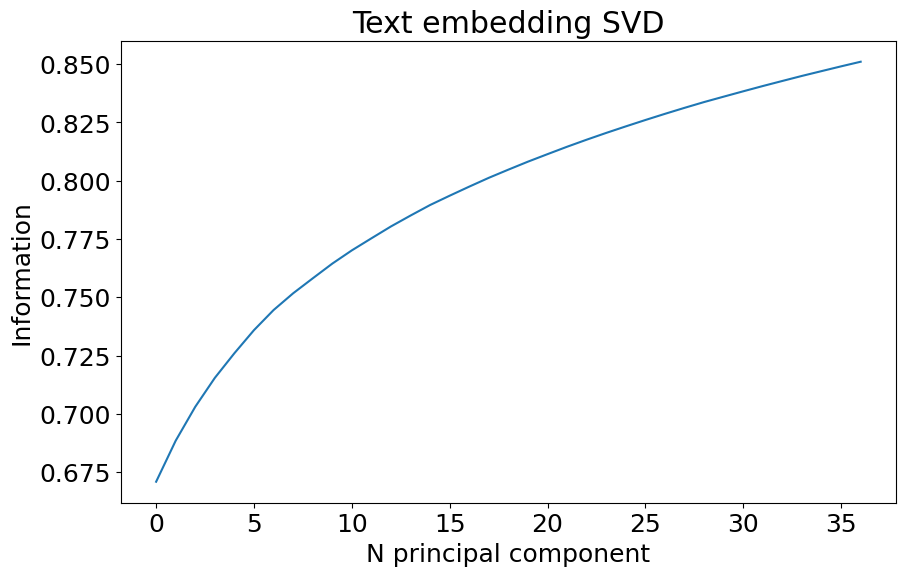

In [52]:
import numpy as np

A = list(X1["img_embeddings_array"].copy())
A = np.asarray(A)
U, S, Vt = np.linalg.svd(A)

# at least 85% of the total variance.
percent = S**2/sum(S**2)
img = []
for i in range(len(percent)):
    if i == 0:
        img.append(percent[i])
    else:
        img.append(img[i-1]+percent[i])

    if ((img[i]) > 0.85 and i > 2):
        break

plt.rc("font", size=18)
plt.figure(figsize=(10,6))
plt.plot(img)
plt.title("Text embedding SVD")
plt.xlabel("N principal component")
plt.ylabel("Information")


for i in range(len(S)):
    X1["img"+str(i)] = U[::][i] *S[i]



Text(0.5, 1.0, 'Image embedding PCA')

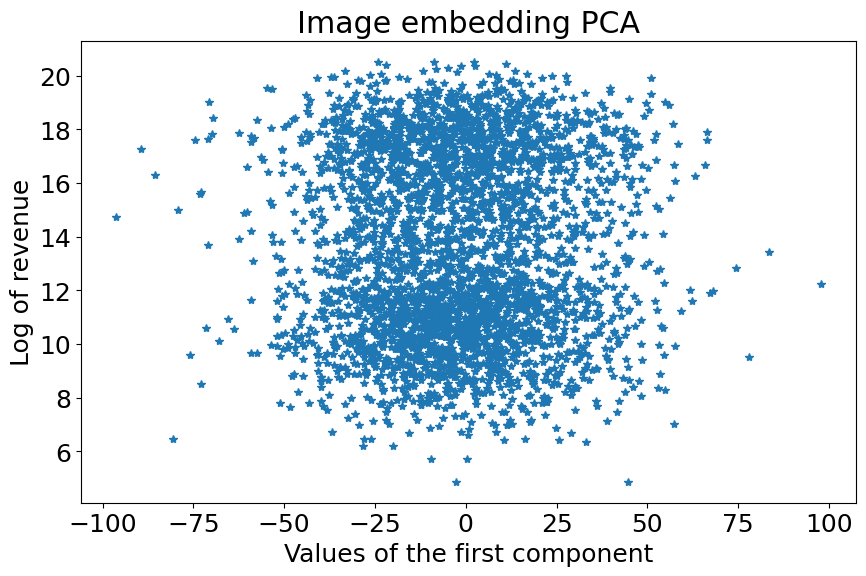

In [53]:

plt.rc("font", size=18)
plt.figure(figsize=(10,6))
plt.plot(X1["img0"], np.log(Y1["revenue"]), '*')
plt.ylabel("Log of revenue")
plt.xlabel("Values of the first component")
plt.title("Image embedding PCA")
# text_embeddings = np.asarray(X1['text_embeddings'])


### Text embeddings

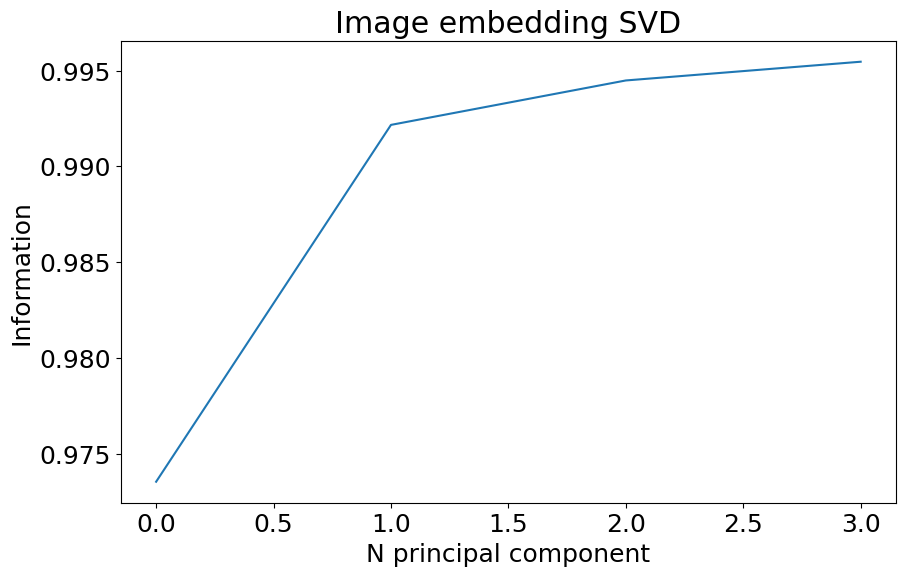

In [54]:
import numpy as np

A = list(X1["text_embeddings_array"].copy())
A = np.asarray(A)
U, S, Vt = np.linalg.svd(A)

# at least 85% of the total variance.
percent = S**2/sum(S**2)
text = []
for i in range(len(percent)):
    if i == 0:
        text.append(percent[i])
    else:
        text.append(text[i-1]+percent[i])

    if ((text[i]) > 0.85 and i >2):
        break

plt.rc("font", size=18)
plt.figure(figsize=(10,6))
plt.plot(text)
plt.title("Image embedding SVD")
plt.xlabel("N principal component")
plt.ylabel("Information")

for i in range(len(S)):
    X1["text"+str(i)] = U[::][i] *S[i]


Text(0.5, 1.0, 'Text embedding PCA')

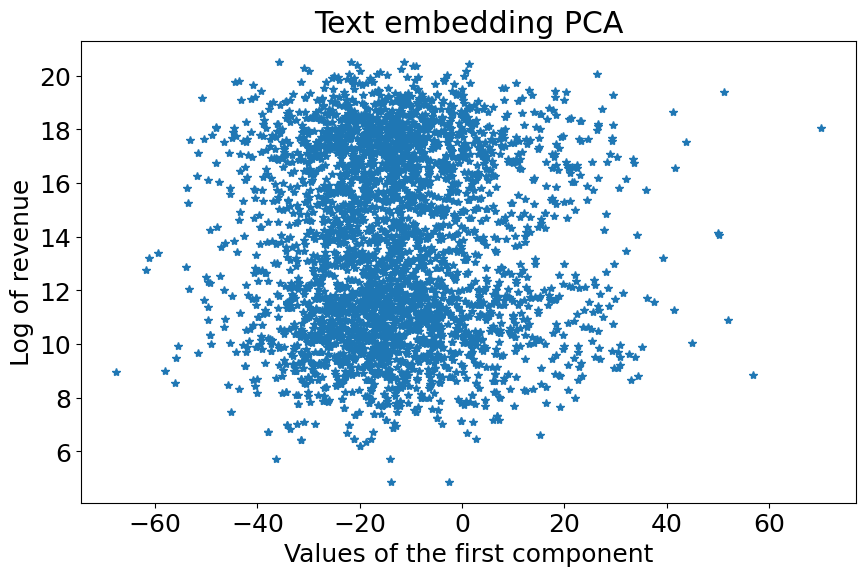

In [55]:

plt.rc("font", size=18)
plt.figure(figsize=(10,6))
plt.plot(X1["text0"], np.log(Y1["revenue"]), '*')
plt.ylabel("Log of revenue")
plt.xlabel("Values of the first component")
plt.title("Text embedding PCA")
# text_embeddings = np.asarray(X1['text_embeddings'])